In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

rng = np.random.RandomState(42)
X, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
N_FEAT, N_CLS = X.shape[1], 10
print("train:", Xtr.shape, "test:", Xte.shape, "clases:", N_CLS)


train: (1347, 64) test: (450, 64) clases: 10


In [2]:
def init_modelo():
    return np.zeros((N_FEAT, N_CLS)), np.zeros(N_CLS)

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    e = np.exp(Z)
    return e / e.sum(axis=1, keepdims=True)

def onehot(y):
    O = np.zeros((len(y), N_CLS))
    O[np.arange(len(y)), y] = 1
    return O

def paso_sgd(W, b, X, y, lr):
    P = softmax(X @ W + b)
    D = (P - onehot(y)) / len(y)
    return W - lr * (X.T @ D), b - lr * D.sum(axis=0)

def accuracy(W, b, X=Xte, y=yte):
    return (np.argmax(X @ W + b, axis=1) == y).mean()

print("Modelo y utilidades listas.")


Modelo y utilidades listas.


In [3]:
def entrenar_centralizado(epocas=200, lr=0.5):
    W, b = init_modelo()
    for _ in range(epocas):
        W, b = paso_sgd(W, b, Xtr, ytr, lr)
    return W, b

Wc, bc = entrenar_centralizado()
acc_central = accuracy(Wc, bc)
print(f"Accuracy centralizada: {acc_central:.3f}")


Accuracy centralizada: 0.967


In [4]:
def particionar_iid(K):
    idx = rng.permutation(len(Xtr))
    return [(Xtr[c], ytr[c]) for c in np.array_split(idx, K)]

K_CLIENTES = 5
clientes_iid = particionar_iid(K_CLIENTES)
print("n° de clientes:", len(clientes_iid))
print("tamaños:", [len(Xc) for Xc, _ in clientes_iid])


n° de clientes: 5
tamaños: [270, 270, 269, 269, 269]


In [5]:
def entrenar_local(W_glob, b_glob, Xc, yc, epocas=25, lr=0.5):
    W, b = W_glob.copy(), b_glob.copy()
    for _ in range(epocas):
        W, b = paso_sgd(W, b, Xc, yc, lr)
    return W, b, len(Xc)

def fedavg(actualizaciones):
    n = sum(nk for _, _, nk in actualizaciones)
    W = sum((nk / n) * Wk for Wk, _, nk in actualizaciones)
    b = sum((nk / n) * bk for _, bk, nk in actualizaciones)
    return W, b

def federado(clientes, R=20, frac=0.4, epocas=25, lr=0.5):
    W, b = init_modelo()
    K, m = len(clientes), max(1, int(frac * len(clientes)))
    historia = []
    for _ in range(R):
        sel = rng.choice(K, m, replace=False)
        ups = [entrenar_local(W, b, *clientes[i][:2], epocas, lr) for i in sel]
        W, b = fedavg(ups)
        historia.append(accuracy(W, b))
    return W, b, historia

Wf_iid, bf_iid, hist_iid = federado(clientes_iid)
print(f"Accuracy federada (IID), última ronda: {hist_iid[-1]:.3f}")


Accuracy federada (IID), última ronda: 0.973


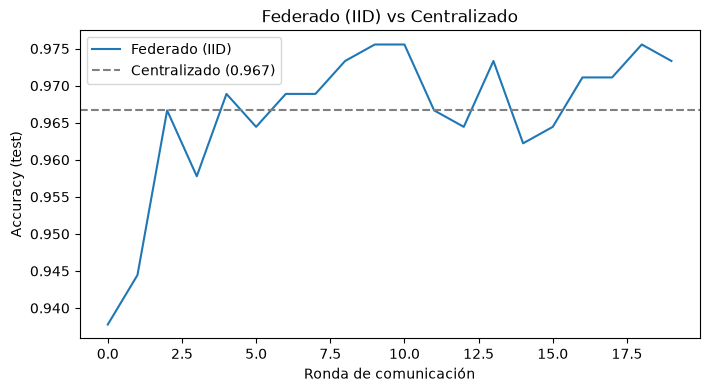

Centralizado: 0.967 | Federado IID (última ronda): 0.973


In [6]:
plt.figure(figsize=(8, 4))
plt.plot(hist_iid, label="Federado (IID)")
plt.axhline(acc_central, color="gray", linestyle="--", label=f"Centralizado ({acc_central:.3f})")
plt.xlabel("Ronda de comunicación")
plt.ylabel("Accuracy (test)")
plt.title("Federado (IID) vs Centralizado")
plt.legend()
plt.show()

print(f"Centralizado: {acc_central:.3f} | Federado IID (última ronda): {hist_iid[-1]:.3f}")


In [7]:
def particionar_non_iid(K, clases_por_cliente=3):
    idx_por_clase = {c: np.where(ytr == c)[0] for c in range(N_CLS)}
    for c in idx_por_clase:
        rng.shuffle(idx_por_clase[c])

    asignacion_clases = [rng.choice(N_CLS, clases_por_cliente, replace=False) for _ in range(K)]

    clientes = []
    for clases_cliente in asignacion_clases:
        idx_cliente = np.concatenate([idx_por_clase[c] for c in clases_cliente])
        rng.shuffle(idx_cliente)
        clientes.append((Xtr[idx_cliente], ytr[idx_cliente]))
    return clientes

clientes_non_iid = particionar_non_iid(K_CLIENTES, clases_por_cliente=3)
print("tamaños non-IID:", [len(Xc) for Xc, _ in clientes_non_iid])
print("clases por cliente (ejemplo cliente 0):", sorted(set(clientes_non_iid[0][1])))


tamaños non-IID: [407, 407, 404, 406, 405]
clases por cliente (ejemplo cliente 0): [np.int64(1), np.int64(3), np.int64(7)]


Accuracy federada (non-IID), última ronda: 0.769


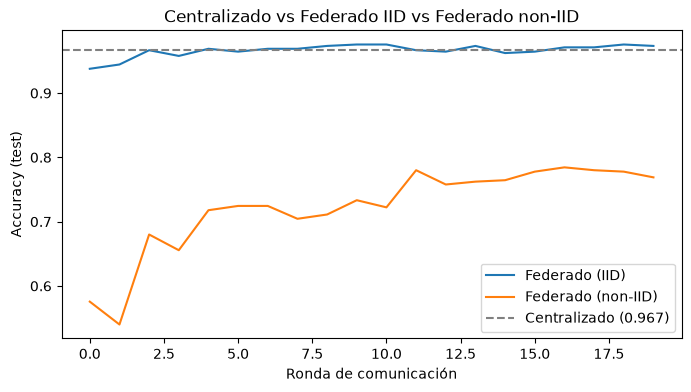

Centralizado:        0.967
Federado IID:         0.973
Federado non-IID:     0.769


In [8]:
Wf_non_iid, bf_non_iid, hist_non_iid = federado(clientes_non_iid)
print(f"Accuracy federada (non-IID), última ronda: {hist_non_iid[-1]:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(hist_iid, label="Federado (IID)")
plt.plot(hist_non_iid, label="Federado (non-IID)")
plt.axhline(acc_central, color="gray", linestyle="--", label=f"Centralizado ({acc_central:.3f})")
plt.xlabel("Ronda de comunicación")
plt.ylabel("Accuracy (test)")
plt.title("Centralizado vs Federado IID vs Federado non-IID")
plt.legend()
plt.show()

print(f"Centralizado:        {acc_central:.3f}")
print(f"Federado IID:         {hist_iid[-1]:.3f}")
print(f"Federado non-IID:     {hist_non_iid[-1]:.3f}")


In [9]:
def entrenar_local_dp(W_glob, b_glob, Xc, yc, epocas=25, lr=0.5, clip_norm=None, noise_std=0.0):
    W, b = W_glob.copy(), b_glob.copy()
    for _ in range(epocas):
        W, b = paso_sgd(W, b, Xc, yc, lr)

    dW, db = W - W_glob, b - b_glob

    if clip_norm is not None:
        norma = np.sqrt((dW ** 2).sum() + (db ** 2).sum())
        factor = min(1.0, clip_norm / (norma + 1e-12))
        dW, db = dW * factor, db * factor

    if noise_std > 0:
        dW = dW + rng.normal(0, noise_std, dW.shape)
        db = db + rng.normal(0, noise_std, db.shape)

    return W_glob + dW, b_glob + db, len(Xc)


def federado_dp(clientes, R=20, frac=0.4, epocas=25, lr=0.5, clip_norm=None, noise_std=0.0):
    W, b = init_modelo()
    K, m = len(clientes), max(1, int(frac * len(clientes)))
    historia = []
    for _ in range(R):
        sel = rng.choice(K, m, replace=False)
        ups = [
            entrenar_local_dp(W, b, *clientes[i][:2], epocas, lr, clip_norm, noise_std)
            for i in sel
        ]
        W, b = fedavg(ups)
        historia.append(accuracy(W, b))
    return W, b, historia


resultados_dp = {}
for noise in [0.0, 0.01, 0.05, 0.1]:
    _, _, hist = federado_dp(clientes_iid, clip_norm=1.0, noise_std=noise)
    resultados_dp[noise] = hist[-1]
    print(f"noise_std={noise:.2f} -> accuracy final: {hist[-1]:.3f}")


noise_std=0.00 -> accuracy final: 0.956
noise_std=0.01 -> accuracy final: 0.969
noise_std=0.05 -> accuracy final: 0.960
noise_std=0.10 -> accuracy final: 0.947


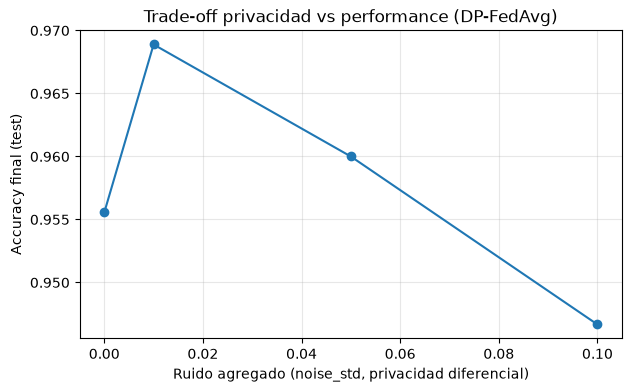

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(list(resultados_dp.keys()), list(resultados_dp.values()), marker="o")
plt.xlabel("Ruido agregado (noise_std, privacidad diferencial)")
plt.ylabel("Accuracy final (test)")
plt.title("Trade-off privacidad vs performance (DP-FedAvg)")
plt.grid(alpha=0.3)
plt.show()
